In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

RESULTS_DIR = '/workspace/spar-team-recon/projects/ip/results/exp_11/XY'

def load_judgements(arm):
    path = f'{RESULTS_DIR}/{arm}/judgements/three_languages.jsonl'
    with open(path) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    data = [r for r in rows if 'overall' not in r]
    summary = [r for r in rows if r.get('overall')][0]
    return data, summary

arms = {
    'arm_0': 'Arm 0 (None, X + Y)',
    'arm_1': 'Arm 1 (X+, X)',
    'arm_2': 'Arm 2 (Y-, X)',
    'arm_3': 'Arm 3 (X+ & Y-, X)',
    'arm_4': 'Arm 4 (X+, Y+)',
    'arm_5': 'Arm 5 (Y-, Y)',
    'arm_6': 'Arm 6 (X+ & Y-, Y)',
    'arm_7': 'Arm 7 (X+, X + Y)',
    'arm_8': 'Arm 8 (Y-, X + Y)',
    'arm_9': 'Arm 9 (X+ & Y-, X + Y)',
}

all_data = {}
all_summaries = {}
for arm in arms:
    all_data[arm], all_summaries[arm] = load_judgements(arm)
    s = all_summaries[arm]
    print(f"{arms[arm]}: spanish={s['mean_spanish_score']:.4f}, french={s['mean_french_score']:.4f}")

Matplotlib is building the font cache; this may take a moment.


Arm 0 (None, X + Y): spanish=45.7513, french=22.8344
Arm 1 (X+, X): spanish=74.8624, french=0.1140
Arm 2 (Y-, X): spanish=73.0736, french=0.0227
Arm 3 (X+ & Y-, X): spanish=80.2855, french=0.2445
Arm 4 (X+, Y+): spanish=0.0003, french=74.9058
Arm 5 (Y-, Y): spanish=0.0002, french=72.8531
Arm 6 (X+ & Y-, Y): spanish=0.0019, french=85.2307
Arm 7 (X+, X + Y): spanish=43.0704, french=38.8961
Arm 8 (Y-, X + Y): spanish=37.0533, french=38.3964
Arm 9 (X+ & Y-, X + Y): spanish=41.1237, french=37.3505


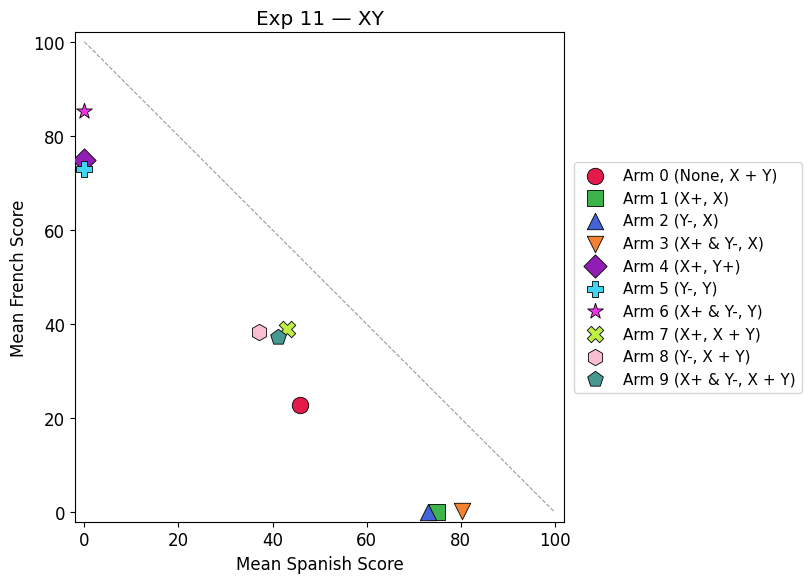

In [3]:
colors = [
    '#e6194B', '#3cb44b', '#4363d8', '#f58231',
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45',
    '#fabed4', '#469990',
]
markers = [
    'o', 's', '^', 'v',
    'D', 'P', '*', 'X',
    'h', 'p',
]

arm_keys = list(arms.keys())

fig, ax = plt.subplots(figsize=(10, 6))

for i, arm in enumerate(arm_keys):
    s = all_summaries[arm]
    ax.scatter(
        s['mean_spanish_score'], s['mean_french_score'],
        color=colors[i], marker=markers[i], s=140, edgecolors='black',
        linewidths=0.6, zorder=3, label=arms[arm],
    )
ax.plot([0, 100], [100, 0], 'k--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('Mean Spanish Score')
ax.set_ylabel('Mean French Score')
ax.set_title('Exp 11 \u2014 XY')
ax.set_xlim(-2, 102)
ax.set_ylim(-2, 102)
ax.set_aspect('equal')
ax.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

plt.tight_layout()
plt.show()